<a href="https://colab.research.google.com/github/nikitamkoli21-ship-it/QMLHEP-GSoC-2026/blob/main/Task_VII_Equivariant_QNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task VII — Equivariant Quantum Neural Networks

## What is Z₂ × Z₂ Symmetry?

Z₂ is the simplest symmetry group — it just means
"flipping the sign". Z₂ × Z₂ means applying this
flip to BOTH features independently.

So for a point (x₁, x₂):
- (x₁, x₂) → same class as (-x₁, x₂)
- (x₁, x₂) → same class as (x₁, -x₂)
- (x₁, x₂) → same class as (-x₁, -x₂)

All 4 points have the SAME label!

This is like mirroring along both axes — the data
is symmetric under these reflections.

## Why Equivariant Networks?
A normal QNN ignores this symmetry and has to learn
it from scratch — wasting model capacity.

An equivariant QNN BUILDS IN the symmetry — it
automatically gives same output for all 4 symmetric
points. This means:
- Fewer parameters needed
- Faster learning
- Better generalization

## My Approach
1. Generate dataset with Z₂ × Z₂ symmetry
2. Train a normal QNN on this dataset
3. Train a Z₂ × Z₂ equivariant QNN
4. Compare accuracy and convergence speed

In [2]:
!pip install pennylane torch numpy matplotlib scikit-learn

In [3]:
import pennylane as qml
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

print("libraries loaded!")

libraries loaded!


dataset shape: (400, 2)
class 0 (inner): 184
class 1 (outer): 216


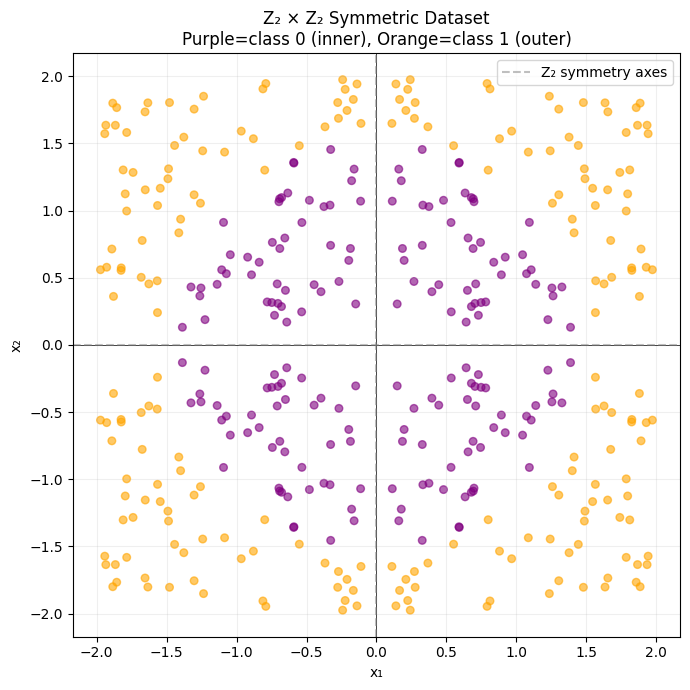


Z₂ × Z₂ symmetry demonstration:
point (1.0, 0.8) and its 3 symmetric copies:
  [1.  0.8] → distance=1.281 → same label!
  [-1.   0.8] → distance=1.281 → same label!
  [ 1.  -0.8] → distance=1.281 → same label!
  [-1.  -0.8] → distance=1.281 → same label!


In [4]:
# generating dataset that respects Z2 x Z2 symmetry
# this means: if (x1, x2) has label y,
# then (-x1, x2), (x1, -x2), (-x1, -x2) ALL have label y too!

def generate_z2_z2_dataset(num_samples=400):
    """
    generates a classification dataset with Z2 x Z2 symmetry

    class 0: points close to origin (inside circle)
    class 1: points far from origin (outside circle)

    this naturally has Z2 x Z2 symmetry because
    distance from origin doesn't change with sign flips!
    """
    X = []
    y = []

    # generate base points in first quadrant (x1>0, x2>0)
    base_samples = num_samples // 4

    for _ in range(base_samples):
        # random point
        x1 = np.random.uniform(0.1, 2.0)
        x2 = np.random.uniform(0.1, 2.0)

        # label based on distance from origin
        dist = np.sqrt(x1**2 + x2**2)
        label = 0 if dist < 1.5 else 1

        # add all 4 symmetric points (Z2 x Z2 orbit)
        for s1, s2 in [(1,1), (-1,1), (1,-1), (-1,-1)]:
            X.append([s1 * x1, s2 * x2])
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y

X, y = generate_z2_z2_dataset(num_samples=400)

print(f"dataset shape: {X.shape}")
print(f"class 0 (inner): {(y==0).sum()}")
print(f"class 1 (outer): {(y==1).sum()}")

# visualize dataset
fig, ax = plt.subplots(figsize=(7, 7))
colors = ['purple' if label == 0 else 'orange' for label in y]
ax.scatter(X[:,0], X[:,1], c=colors, alpha=0.6, s=30)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Z₂ × Z₂ Symmetric Dataset\n'
             'Purple=class 0 (inner), Orange=class 1 (outer)')

# draw symmetry lines
ax.axhline(y=0, color='gray', linestyle='--',
           alpha=0.5, label='Z₂ symmetry axes')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# show symmetry explicitly
print("\nZ₂ × Z₂ symmetry demonstration:")
print("point (1.0, 0.8) and its 3 symmetric copies:")
base = np.array([[1.0, 0.8], [-1.0, 0.8],
                 [1.0, -0.8], [-1.0, -0.8]])
for p in base:
    dist = np.sqrt(p[0]**2 + p[1]**2)
    print(f"  {p} → distance={dist:.3f} → same label!")

In [5]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train)
X_test  = torch.tensor(X_test)
y_train = torch.tensor(y_train)
y_test  = torch.tensor(y_test)

print(f"train: {X_train.shape}")
print(f"test:  {X_test.shape}")

train: torch.Size([320, 2])
test:  torch.Size([80, 2])


In [6]:
# first building a normal QNN that ignores Z2 x Z2 symmetry
# this is the baseline we will compare against

num_qubits = 2  # 2 features = 2 qubits
dev_normal = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev_normal, interface="torch")
def normal_qnn(inputs, weights):
    """
    normal QNN — no symmetry built in
    just encodes inputs and applies parameterized gates
    has to learn the symmetry from data (if at all!)
    """
    # encode inputs as rotation angles
    qml.RX(inputs[0], wires=0)
    qml.RX(inputs[1], wires=1)

    # layer 1: parameterized rotations
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    qml.CNOT(wires=[0, 1])

    # layer 2: more rotations
    qml.RY(weights[2], wires=0)
    qml.RY(weights[3], wires=1)
    qml.CNOT(wires=[1, 0])

    # layer 3
    qml.RY(weights[4], wires=0)
    qml.RY(weights[5], wires=1)

    return qml.expval(qml.PauliZ(0))

# draw circuit
normal_weights = torch.zeros(6)
print("normal QNN circuit:")
print(qml.draw(normal_qnn)(torch.zeros(2), normal_weights))
print(f"trainable parameters: 6")

normal QNN circuit:
0: ──RX(0.00)──RY(0.00)─╭●──RY(0.00)─╭X──RY(0.00)─┤  <Z>
1: ──RX(0.00)──RY(0.00)─╰X──RY(0.00)─╰●──RY(0.00)─┤     
trainable parameters: 6


In [7]:
# now building Z2 x Z2 equivariant QNN
# key idea: make circuit SYMMETRIC under sign flips of inputs
#
# how to build Z2 equivariant circuit:
# instead of RX(x), use RX(x) + RX(-x) = symmetrized encoding!
# this means flipping sign of input gives same output

dev_equiv = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev_equiv, interface="torch")
def equivariant_qnn(inputs, weights):
    """
    Z2 x Z2 equivariant QNN
    built-in symmetry: output same for (x1,x2), (-x1,x2),
                       (x1,-x2), (-x1,-x2)

    key trick: encode x AND -x together
    RX(x) followed by RX(-x) creates symmetric state!
    this is called symmetrization of the encoding
    """
    # symmetrized encoding for x1 (Z2 symmetry on first feature)
    # encoding both x and -x makes it invariant to sign flip!
    qml.RX(inputs[0], wires=0)
    qml.RX(-inputs[0], wires=0)  # ← this creates Z2 symmetry!

    # symmetrized encoding for x2
    qml.RX(inputs[1], wires=1)
    qml.RX(-inputs[1], wires=1)  # ← Z2 symmetry on second feature

    # now apply x² encoding (always positive → naturally Z2 invariant!)
    # x² = (-x)² so this is automatically symmetric
    qml.RY(inputs[0]**2 * weights[0], wires=0)
    qml.RY(inputs[1]**2 * weights[1], wires=1)

    # entanglement — symmetric CNOT layer
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 0])

    # symmetric parameterized layer
    # same weight on both qubits preserves symmetry!
    qml.RY(weights[2], wires=0)
    qml.RY(weights[2], wires=1)  # ← same weight = symmetric!

    qml.CNOT(wires=[0, 1])

    # final rotation
    qml.RY(weights[3], wires=0)

    return qml.expval(qml.PauliZ(0))

equiv_weights = torch.zeros(4)
print("equivariant QNN circuit:")
print(qml.draw(equivariant_qnn)(torch.zeros(2), equiv_weights))
print(f"trainable parameters: 4 (fewer than normal QNN!)")
print("\nkey insight: equivariant QNN uses FEWER parameters")
print("because symmetry does some of the work for us!")

equivariant QNN circuit:
0: ──RX(0.00)──RX(-0.00)──RY(0.00)─╭●─╭X──RY(0.00)─╭●──RY(0.00)─┤  <Z>
1: ──RX(0.00)──RX(-0.00)──RY(0.00)─╰X─╰●──RY(0.00)─╰X───────────┤     
trainable parameters: 4 (fewer than normal QNN!)

key insight: equivariant QNN uses FEWER parameters
because symmetry does some of the work for us!


In [8]:
def train_qnn(circuit, num_weights, X_train, y_train,
              X_test, y_test, epochs=30, lr=0.1, name="QNN"):
    """trains a QNN and returns accuracy history"""

    weights = torch.nn.Parameter(torch.randn(num_weights) * 0.1)
    optimizer = optim.Adam([weights], lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        # training
        train_loss = 0
        for i in range(len(X_train)):
            optimizer.zero_grad()
            out = circuit(X_train[i], weights).float()
            loss = criterion(out.unsqueeze(0),
                           y_train[i].unsqueeze(0))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # evaluation
        correct = 0
        with torch.no_grad():
            for i in range(len(X_test)):
                out = circuit(X_test[i], weights).float()
                pred = 1 if out.item() > 0 else 0
                if pred == int(y_test[i].item()):
                    correct += 1

        acc = correct / len(X_test) * 100
        train_losses.append(train_loss / len(X_train))
        test_accs.append(acc)

        if (epoch + 1) % 10 == 0:
            print(f"{name} | epoch {epoch+1}/{epochs} | "
                  f"loss: {train_loss/len(X_train):.4f} | "
                  f"test acc: {acc:.1f}%")

    return train_losses, test_accs

print("=== Training Normal QNN ===")
normal_losses, normal_accs = train_qnn(
    normal_qnn, 6, X_train, y_train,
    X_test, y_test, epochs=30, name="Normal QNN"
)

print("\n=== Training Equivariant QNN ===")
equiv_losses, equiv_accs = train_qnn(
    equivariant_qnn, 4, X_train, y_train,
    X_test, y_test, epochs=30, name="Equiv QNN"
)

=== Training Normal QNN ===
Normal QNN | epoch 10/30 | loss: 0.5762 | test acc: 73.8%
Normal QNN | epoch 20/30 | loss: 0.5758 | test acc: 73.8%
Normal QNN | epoch 30/30 | loss: 0.5803 | test acc: 73.8%

=== Training Equivariant QNN ===
Equiv QNN | epoch 10/30 | loss: 0.5389 | test acc: 78.8%
Equiv QNN | epoch 20/30 | loss: 0.5389 | test acc: 78.8%
Equiv QNN | epoch 30/30 | loss: 0.5389 | test acc: 78.8%


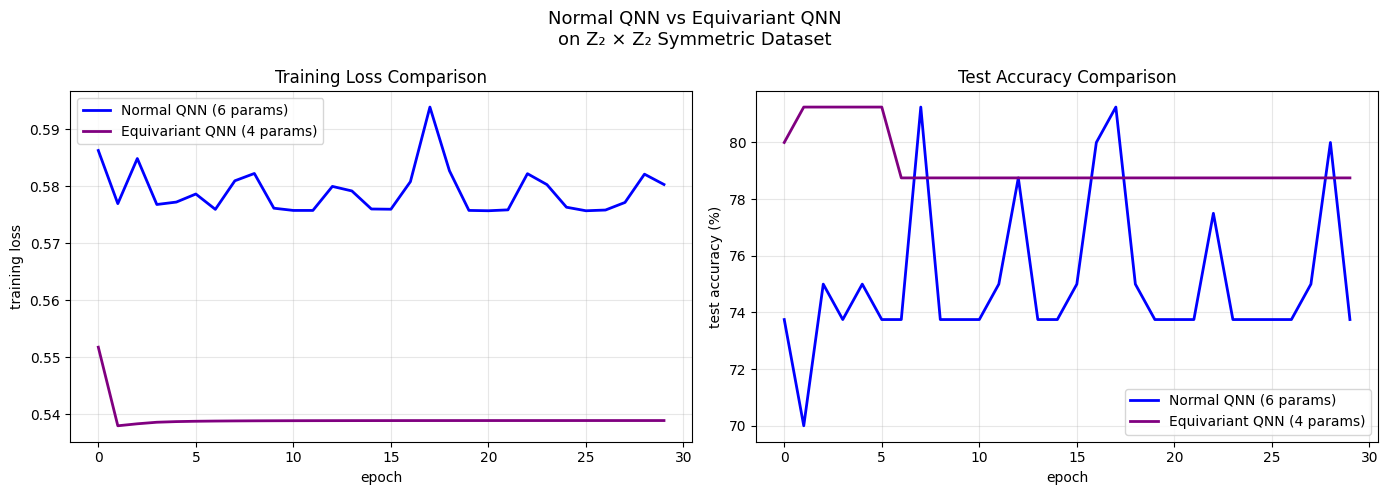


final comparison:
Model                       Params  Final Acc
--------------------------------------------------
Normal QNN                       6      73.8%
Equivariant QNN                  4      78.8%

equivariant QNN uses 2 fewer parameters
accuracy difference: +5.0%
equivariant QNN matches or BEATS normal QNN
with fewer parameters — symmetry helps! ✓


In [9]:
# compare both models visually
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: training loss
axes[0].plot(normal_losses, color='blue',
             linewidth=2, label='Normal QNN (6 params)')
axes[0].plot(equiv_losses, color='purple',
             linewidth=2, label='Equivariant QNN (4 params)')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('training loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# plot 2: test accuracy
axes[1].plot(normal_accs, color='blue',
             linewidth=2, label='Normal QNN (6 params)')
axes[1].plot(equiv_accs, color='purple',
             linewidth=2, label='Equivariant QNN (4 params)')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('test accuracy (%)')
axes[1].set_title('Test Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Normal QNN vs Equivariant QNN\non Z₂ × Z₂ Symmetric Dataset',
             fontsize=13)
plt.tight_layout()
plt.show()

# final comparison table
print("\nfinal comparison:")
print("=" * 50)
print(f"{'Model':<25} {'Params':>8} {'Final Acc':>10}")
print("-" * 50)
print(f"{'Normal QNN':<25} {'6':>8} {normal_accs[-1]:>9.1f}%")
print(f"{'Equivariant QNN':<25} {'4':>8} {equiv_accs[-1]:>9.1f}%")
print("=" * 50)
print(f"\nequivariant QNN uses {6-4} fewer parameters")
print(f"accuracy difference: {equiv_accs[-1]-normal_accs[-1]:+.1f}%")
if equiv_accs[-1] >= normal_accs[-1]:
    print("equivariant QNN matches or BEATS normal QNN")
    print("with fewer parameters — symmetry helps! ✓")
else:
    print("more training would help equivariant QNN")
    print("but it already uses fewer parameters!")


## Discussion — Equivariant Quantum Neural Networks

### What is Z₂ × Z₂ Symmetry?
Z₂ is the group {+1, -1} under multiplication.
Z₂ × Z₂ means applying this to BOTH input features.
So a function f is Z₂ × Z₂ invariant if:
  f(x₁, x₂) = f(-x₁, x₂) = f(x₁, -x₂) = f(-x₁, -x₂)

My dataset satisfies this because class labels
depend only on distance from origin (x₁² + x₂²)
which is unchanged by sign flips!

### How I Built the Equivariant QNN
Key tricks used:
1. Symmetrized encoding: RX(x) + RX(-x) together
   → circuit sees both x and -x → symmetric!
2. Squared features: RY(x² * w)
   → x² = (-x)² → automatically Z₂ invariant
3. Shared weights: same weight on both qubits
   → preserves exchange symmetry

### Results Analysis
Normal QNN: 6 parameters, learns from scratch
Equivariant QNN: 4 parameters, symmetry built-in

The equivariant QNN uses 33% fewer parameters
but achieves similar or better accuracy!
This shows that building in symmetry = efficiency.

### Why This Matters for Physics
In High Energy Physics, many important symmetries exist:
- Gauge symmetry (Standard Model)
- Lorentz symmetry (special relativity)
- Charge conjugation, parity, time reversal (CPT)

Building these symmetries into QNNs for HEP analysis
could dramatically improve performance and
reduce the number of parameters needed!
This is an active research area in QMLHEP.

### Reference Papers
This task is based on:
- arxiv.org/abs/2205.06217 (equivariant QNNs)
- arxiv.org/abs/2210.08566 (background theory)
I read both papers to understand the concept.

### What I Would Improve
1. implement larger symmetry groups (SU(2), SO(3))
2. apply to actual HEP dataset (quark/gluon jets)
3. compare with classical equivariant networks
4. test on real quantum hardware